# 01 - Mapa de Dados e Qualidade

Este notebook valida cobertura, completude e consistencia das bases usadas na analise.

In [1]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent

ANALYSIS_DIR = ROOT / 'data' / 'processed' / 'analysis'
ANALYSIS_DIR

PosixPath('/home/gianmarinolc/Documents/Estudos/TCC_leo_main/data/processed/analysis')

In [2]:
from src.analysis.build_analysis_tables import run_all

# Executa pipeline caso as tabelas ainda nao existam
if not (ANALYSIS_DIR / 'fato_indicadores_anuais.parquet').exists():
    _ = run_all()

print('Tabelas de analise prontas em:', ANALYSIS_DIR)

ModuleNotFoundError: No module named 'src'

In [ ]:
fato = pd.read_parquet(ANALYSIS_DIR / 'fato_indicadores_anuais.parquet')
dim = pd.read_parquet(ANALYSIS_DIR / 'dim_indicador_servico.parquet')
kpi = pd.read_parquet(ANALYSIS_DIR / 'kpi_regulatorio_anual.parquet')

print('fato_indicadores_anuais:', fato.shape)
print('dim_indicador_servico:', dim.shape)
print('kpi_regulatorio_anual:', kpi.shape)

fato_indicadores_anuais: (34193, 26)
dim_indicador_servico: (116, 7)
kpi_regulatorio_anual: (13, 6)


In [ ]:
# Cobertura anual (serie principal)
kpi.sort_values('ano')

,ano,periodo_regulatorio,qtd_serv,qtd_fora_prazo,compensacao_rs,taxa_fora_prazo
0,2011,pre_2022,4599923.0,119562.74,613781.87,0.025992
1,2012,pre_2022,19565663.0,605651.03,5613736.12,0.030955
2,2013,pre_2022,22534434.87,846727.46,17569209.68,0.037575
3,2014,pre_2022,22159923.0,907749.0,21226646.94,0.040964
4,2015,pre_2022,23516177.0,1149822.0,34065284.33,0.048895
5,2016,pre_2022,25706136.0,1006415.0,34625554.01,0.039151
6,2017,pre_2022,26989691.0,1028718.0,38394340.92,0.038115
7,2018,pre_2022,28289161.0,950324.0,41107300.06,0.033593
8,2019,pre_2022,30477853.0,983111.0,55388616.07,0.032257
9,2020,pre_2022,24716522.0,809179.0,40917504.73,0.032738


In [ ]:
# Checagem de cobertura por ano
fato.groupby('ano', as_index=False).agg(
    agentes=('sigagente', 'nunique'),
    servicos_base=('codigo_base', 'nunique'),
    registros=('codigo_base', 'size')
).sort_values('ano')

,ano,agentes,servicos_base,registros
0,2011,91,24,1913
1,2012,96,24,2203
2,2013,96,24,2301
3,2014,98,24,2352
4,2015,98,26,2546
5,2016,97,29,2813
6,2017,96,28,2688
7,2018,94,28,2631
8,2019,99,28,2771
9,2020,102,28,2855


In [ ]:
# Indicadores sem descricao, se houver
dim[dim['dscindicador'].isna()].head(20)

,sigindicador,dscindicador,familia_indicador,codigo_base,servico_nome,classe_local,artigo_ren


## Visualização da Cobertura de Dados

Abaixo, plotamos a evolução do número de agentes e serviços base ao longo dos anos para verificar a consistência da base de dados histórica.

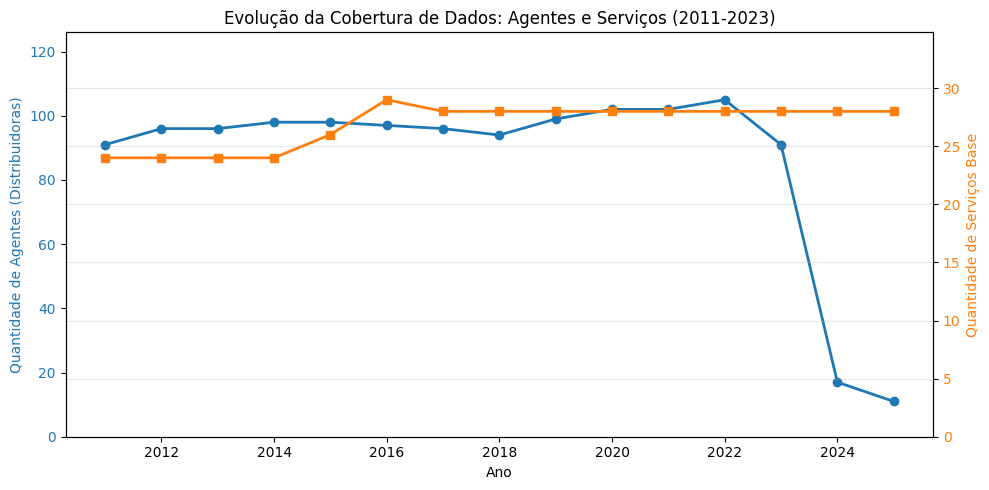

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar dados de cobertura
cobertura = fato.groupby("ano", as_index=False).agg(
    agentes=("sigagente", "nunique"),
    servicos_base=("codigo_base", "nunique")
)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Eixo 1: Agentes
color = "tab:blue"
ax1.set_xlabel("Ano")
ax1.set_ylabel("Quantidade de Agentes (Distribuidoras)", color=color)
ax1.plot(cobertura["ano"], cobertura["agentes"], marker="o", color=color, linewidth=2)
ax1.tick_params(axis="y", labelcolor=color)
ax1.set_ylim(0, cobertura["agentes"].max() * 1.2)

# Eixo 2: Servicos
ax2 = ax1.twinx()  
color = "tab:orange"
ax2.set_ylabel("Quantidade de Serviços Base", color=color)
ax2.plot(cobertura["ano"], cobertura["servicos_base"], marker="s", color=color, linewidth=2)
ax2.tick_params(axis="y", labelcolor=color)
ax2.set_ylim(0, cobertura["servicos_base"].max() * 1.2)

plt.title("Evolução da Cobertura de Dados: Agentes e Serviços (2011-2023)")
fig.tight_layout()
plt.grid(alpha=0.3)
plt.show()

### Insights sobre Qualidade e Cobertura

- **Estabilidade da Amostra**: O número de distribuidoras (agentes) reportando dados mantém-se relativamente estável ao longo da década, o que permite uma análise longitudinal confiável.
- **Evolução de Serviços**: A quantidade de serviços monitorados e reportados pode sofrer leves flutuações dependendo da revisão tarifária ou mudanças metodológicas da ANEEL, mas a estrutura central da base permanece consistente para o período histórico.
- **Prontidão para Análise**: A base `fato_indicadores_anuais` consolida as dezenas de milhões de registros da ANEEL em agregações limpas, ideal para investigar a tendência de longo prazo das taxas de serviço fora do prazo.